# 🎓 Scholarship Recommendation System
## Advanced ML: SVM · Naive Bayes · TF-IDF · Cosine Similarity · Content-Based Filtering

---

### What This Notebook Covers

| # | Algorithm | Type | Input |
|---|---|---|---|
| 1 | **TF-IDF Vectorization** | NLP / Text | Course, occupation, strand (text fields) |
| 2 | **Cosine Similarity + Content-Based Filtering** | Recommendation | TF-IDF vectors |
| 3 | **Naive Bayes — Gaussian** | Probabilistic ML | Numeric features |
| 4 | **Naive Bayes — Complement** | Probabilistic ML | TF-IDF features |
| 5 | **SVM — RBF Kernel** | Kernel ML | Numeric + TF-IDF combined |
| 6 | **SVM — Linear Kernel** | Kernel ML | Numeric + TF-IDF combined |
| 7 | **Random Forest** | Ensemble ML | Numeric + TF-IDF combined |
| 8 | **Gradient Boosting** | Ensemble ML | Numeric + TF-IDF combined |
| 9 | **Weighted Soft Voting Ensemble** | Combined | All models |

### Verified Results (3,340 rows, 13 classes)
| Model | Accuracy | Macro F1 |
|---|---|---|
| Cosine Similarity (Content-Based) | 30.54% | 25.79% |
| Complement NB (TF-IDF only) | 30.54% | 23.55% |
| Gaussian NB (Numeric) | 53.29% | 51.19% |
| SVM RBF (Numeric + TF-IDF) | 60.33% | 59.68% |
| SVM Linear (Numeric + TF-IDF) | 64.52% | 64.05% |
| Gradient Boosting | 65.87% | 65.07% |
| Random Forest | 66.47% | 65.12% |
| **Weighted Ensemble (All)** | **67.37%** | **66.10%** |

### Dataset
- `scholarship_dataset_expanded.csv` — 3,340 rows 
- 13 scholarship classes, 80/20 stratified split

## Cell 1 — Import Libraries

In [31]:
import re
import warnings
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Preprocessing ─────────────────────────────────────────────
from sklearn.preprocessing          import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.impute                  import SimpleImputer
from sklearn.compose                 import ColumnTransformer
from sklearn.preprocessing          import OneHotEncoder

# ── NLP ───────────────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise        import cosine_similarity

# ── Models ────────────────────────────────────────────────────
from sklearn.svm                    import SVC
from sklearn.naive_bayes            import GaussianNB, ComplementNB
from sklearn.ensemble               import RandomForestClassifier, GradientBoostingClassifier

# ── Pipeline & Evaluation ─────────────────────────────────────
from sklearn.pipeline               import Pipeline
from sklearn.model_selection        import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics                import (accuracy_score, f1_score,
                                             classification_report,
                                             confusion_matrix,
                                             ConfusionMatrixDisplay,
                                             precision_recall_fscore_support)
import joblib

warnings.filterwarnings('ignore')
os.makedirs('outputs', exist_ok=True)
print("✅ Libraries imported.")

✅ Libraries imported.


## Cell 2 — Load Dataset

Use `scholarship_dataset_expanded.csv` (3,340 rows).  
If you only have the original dirty CSV, replace with `scholarship_dataset_dirty.csv`.

In [32]:
df = pd.read_csv('scholarship_dataset_expanded.csv')

print(f"Shape  : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nClass distribution:")
print(df['scholarship_label'].value_counts())
print(f"\nMissing values (columns with gaps):")
print(df.isnull().sum()[df.isnull().sum() > 0])
df.head(3)

Shape  : 3340 rows × 28 columns

Class distribution:
scholarship_label
DOST Undergraduate Scholarship    265
CHED TES                          265
CHED TDP                          265
ACEF-GIAHEP                       255
CHED CoScho                       255
BRO-ED ISU Cauayan                255
CHED Merit - Half                 255
College Scholar                   255
CHED SIDA                         255
No Scholarship Recommended        255
CHED Merit - Full                 255
University Scholar                255
CHED SIKAP                        250
Name: count, dtype: int64

Missing values (columns with gaps):
province                    36
gwa_percentage              32
gwa_numeric_1to5            39
family_annual_income_php    57
family_size                 36
is_pwd                      67
is_4ps_beneficiary          73
is_ofw_dependent            36
parents_occupation          36
high_school_type            55
dtype: int64


,student_id,first_name,last_name,age,sex,civil_status,region,province,municipality,barangay_type,...,is_pwd,is_indigenous_people,is_4ps_beneficiary,is_ofw_dependent,parents_occupation,high_school_type,shs_strand,enrolled_hei_type,has_existing_scholarship,scholarship_label
0,1001,Glenda,Panganiban,23,Female,Single,Region V,Bicol,Santiago City,Urban,...,No,No,No,Yes,NaN,Public,STEM,SUC,No,CHED CoScho
1,1002,Karen,Aquino,17,Females,Single,Region II,Isabela,Ilagan City,Rural,...,No,N,No,No,Driver/Tricycle Operator,Public,STEM,Prvate HEI,No,DOST Undergraduate Scholarship
2,1003,Andrei,Cruz,18,Male,Single,Region II,Isabela,Ilagan City,Rural,...,No,No,Yes,NaN,Unemployed,Private,STEM,LUC,No,CHED CoScho


## Cell 3 — Data Cleaning

The original dataset has many inconsistencies:

| Column | Problem | Fix |
|---|---|---|
| `sex` | 'Male', 'MALE', 'm', 'Females' | Normalize to 'Male'/'Female' |
| `enrolled_hei_type` | 17 variants of 3 values | Map to SUC / LUC / Private HEI |
| `shs_strand` | 'S.T.E.M', 'Steem', 'STERM' | Map to STEM / ABM / HUMSS/GAS |
| `barangay_type` | 'Rurall', 'Rular', 'URBAN' | Map to Rural / Urban |
| `course_category` | 'Enginnering', 'Busines' | Correct typos |
| Boolean flags | 'Yes', 'YES', 'y', 'nope', '1' | Convert to 1.0 / 0.0 |
| `gwa_percentage` | Some rows missing; `gwa_numeric_1to5` present | Cross-derive |

In [33]:
YES_VALS = {'yes', 'y', '1', 'true', 'yep'}
NO_VALS  = {'no',  'n', '0', 'false', 'nope', 'nop'}

def clean_binary(v):
    """Yes/No/1/0/nope → 1.0 or 0.0"""
    if pd.isna(v): return np.nan
    s = str(v).strip().lower()
    if s in YES_VALS: return 1.0
    if s in NO_VALS:  return 0.0
    return np.nan

def clean_sex(v):
    if pd.isna(v): return 'Unknown'
    s = str(v).strip().lower()
    return 'Female' if s.startswith('f') else ('Male' if s.startswith('m') else 'Unknown')

def clean_civil(v):
    if pd.isna(v): return 'Unknown'
    return {'single':'Single', 'married':'Married', 'widowed':'Widowed',
            'singe':'Single', 'sngle':'Single'}.get(str(v).strip().lower(), 'Unknown')

def clean_hei(v):
    if pd.isna(v): return 'Unknown'
    s = re.sub(r'[\s._-]+', '', str(v).strip().lower())
    if 'suc' in s or 'stateuniversity' in s: return 'SUC'
    if 'luc' in s or 'localuniversity' in s: return 'LUC'
    if 'private' in s:                       return 'Private HEI'
    return 'Unknown'

def clean_strand(v):
    if pd.isna(v): return 'Unknown'
    s = str(v).strip().lower()
    if 'stem' in s:                              return 'STEM'
    if 'abm' in s and 'tvl' in s:               return 'TVL/ABM'
    if 'abm' in s:                               return 'ABM'
    if 'humss' in s or 'gas' in s or 'academic' in s: return 'HUMSS/GAS'
    if 'tvl' in s:                               return 'TVL'
    return 'Other'

def clean_bar(v):
    if pd.isna(v): return 'Unknown'
    s = str(v).strip().lower()
    return 'Urban' if 'urban' in s else ('Rural' if 'rural' in s else 'Unknown')

def clean_cat(v):
    if pd.isna(v): return 'Unknown'
    s = str(v).strip().lower()
    MAP = {
        'coconut-related':  'Coconut-Related',  'sugarcane-related': 'Sugarcane-Related',
        'engineering':      'Engineering',       'enginnering':       'Engineering',
        'agriculture':      'Agriculture',       'agriulture':        'Agriculture',
        'health sciences':  'Health Sciences',   'health sciencess':  'Health Sciences',
        'health science':   'Health Sciences',   'helath sciences':   'Health Sciences',
        'science':          'Science',           'sience':            'Science',
        'sciience':         'Science',
        'social sciences':  'Social Sciences',   'hospitality':       'Hospitality',
        'it/computing':     'IT/Computing',       'i.t/computing':     'IT/Computing',
        'business':         'Business',          'bussiness':         'Business',
        'buisness':         'Business',          'busines':           'Business',
        'education':        'Education',
    }
    for k, val in MAP.items():
        if k in s: return val
    return s.title()

def clean_region(v):
    if pd.isna(v): return 'Unknown'
    return re.sub(r'\s+', ' ', str(v).strip())

# ── Apply ─────────────────────────────────────────────────────
df['sex']               = df['sex'].apply(clean_sex)
df['civil_status']      = df['civil_status'].apply(clean_civil)
df['enrolled_hei_type'] = df['enrolled_hei_type'].apply(clean_hei)
df['shs_strand']        = df['shs_strand'].apply(clean_strand)
df['barangay_type']     = df['barangay_type'].apply(clean_bar)
df['course_category']   = df['course_category'].apply(clean_cat)
df['region']            = df['region'].apply(clean_region)

BINARY_COLS = ['is_solo_parent_dependent', 'is_pwd', 'is_indigenous_people',
               'is_4ps_beneficiary', 'is_ofw_dependent', 'has_existing_scholarship']
for col in BINARY_COLS:
    df[col] = df[col].apply(clean_binary)

NUMERIC_COLS = ['gwa_percentage', 'gwa_numeric_1to5',
                'family_annual_income_php', 'family_size', 'age', 'year_level']
for col in NUMERIC_COLS:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Cross-fill missing GWA values
mask = df['gwa_percentage'].isna() & df['gwa_numeric_1to5'].notna()
df.loc[mask, 'gwa_percentage'] = 100 - (df.loc[mask, 'gwa_numeric_1to5'] - 1) * 7.5
mask = df['gwa_numeric_1to5'].isna() & df['gwa_percentage'].notna()
df.loc[mask, 'gwa_numeric_1to5'] = (100 - df.loc[mask, 'gwa_percentage']) / 7.5 + 1

print("✅ Cleaning complete.")
print(f"Missing values remaining:\n{df[NUMERIC_COLS].isnull().sum()}")

✅ Cleaning complete.
Missing values remaining:
gwa_percentage               0
gwa_numeric_1to5             0
family_annual_income_php    57
family_size                 36
age                          0
year_level                   0
dtype: int64


## Cell 4 — Build Student Text Profile (for TF-IDF)

### What is TF-IDF?
**TF-IDF** (Term Frequency–Inverse Document Frequency) converts text into numbers.

- **TF** (Term Frequency) = how often a word appears in a document
- **IDF** (Inverse Document Frequency) = penalizes common words, rewards rare/unique words
- **Result** = a numeric vector where each dimension = one word's importance score

### Why do we need this?
Our dataset has text-like fields (course name, occupation, SHS strand, region) that
traditional ML models can't use directly. TF-IDF turns them into a 500-dimension numeric
vector that captures *what kind of student this is*.

### Text Profile Construction
Each student gets one "document" by concatenating their key fields:
```
"bs nursing health_sciences stem region_ii suc rural 4ps_beneficiary 4ps_beneficiary 4ps_beneficiary"
```
Vulnerability flags (4Ps, OFW, etc.) are **repeated 2–3×** so TF-IDF assigns them higher weight.

In [34]:
def build_text_profile(row):
    """
    Creates a text document from a student's qualitative fields.

    Strategy:
    - Concatenate course, category, strand, region, HEI, barangay, occupation
    - Repeat vulnerability keywords (4ps, ofw, etc.) to boost their TF-IDF weight
    - All text lowercased and cleaned

    Returns
    -------
    str: a single text string representing the student's academic profile
    """
    parts = []

    # Core academic identity fields
    parts.append(str(row.get('course',              '') or '').lower().strip())
    parts.append(str(row.get('course_category',     '') or '').lower().strip())
    parts.append(str(row.get('shs_strand',          '') or '').lower().strip())
    parts.append(str(row.get('region',              '') or '').lower().strip())
    parts.append(str(row.get('enrolled_hei_type',   '') or '').lower().strip())
    parts.append(str(row.get('barangay_type',       '') or '').lower().strip())

    occ = str(row.get('parents_occupation', '') or '').lower().strip()
    if occ and occ != 'nan':
        parts.append(occ)

    # Repeat vulnerability flags for higher TF-IDF weight
    if row.get('is_4ps_beneficiary')       == 1.0: parts += ['4ps_beneficiary']  * 3
    if row.get('is_ofw_dependent')         == 1.0: parts += ['ofw_dependent']    * 2
    if row.get('is_indigenous_people')     == 1.0: parts += ['indigenous_people']* 2
    if row.get('is_pwd')                   == 1.0: parts += ['pwd']              * 2
    if row.get('is_solo_parent_dependent') == 1.0: parts += ['solo_parent']      * 2

    return ' '.join(p for p in parts if p and p != 'nan')


df['text_profile'] = df.apply(build_text_profile, axis=1)

print("✅ Text profiles created.")
print("\nSample profiles:")
for label in df['scholarship_label'].unique()[:4]:
    row = df[df['scholarship_label'] == label].iloc[0]
    print(f"\n  [{label}]")
    print(f"  {row['text_profile'][:120]}...")

✅ Text profiles created.

Sample profiles:

  [CHED CoScho]
  bs agricultural engineering (coconut) coconut-related stem region v suc urban ofw_dependent ofw_dependent...

  [DOST Undergraduate Scholarship]
  bs information technology it/computing stem region ii unknown rural driver/tricycle operator solo_parent solo_parent...

  [ACEF-GIAHEP]
  bs fisheries agriculture stem region ii luc rural fisherfolk indigenous_people indigenous_people...

  [BRO-ED ISU Cauayan]
  bs environmental science science stem region ii luc rural vendor/small business...


## Cell 5 — Feature Engineering

Domain-specific features encode **scholarship eligibility rules directly** as numeric signals.
This dramatically improves model performance over raw features alone.

In [35]:
g   = df['gwa_percentage'].fillna(0)
inc = df['family_annual_income_php'].fillna(0)

# ── GWA Fine Tier — 9 levels ──────────────────────────────────
# Separates University Scholar (97-100%) from College Scholar (95-97%)
# from Merit Half (93-95%), DOST (85-99%), etc.
def gwa_fine_tier(x):
    if pd.isna(x): return 4
    if x >= 97: return 9    # University Scholar zone
    if x >= 95: return 8    # College Scholar zone
    if x >= 93: return 7    # Merit Half zone
    if x >= 91: return 6
    if x >= 88: return 5
    if x >= 85: return 4
    if x >= 82: return 3
    if x >= 78: return 2
    return 1                # No Scholarship zone

# ── Income Tier — 8 levels ────────────────────────────────────
# No Scholarship: >₱430K | CHED SIDA: <₱200K | TES: <₱290K
def income_tier(x):
    if pd.isna(x): return 3
    if x < 100_000: return 1
    if x < 150_000: return 2
    if x < 200_000: return 3
    if x < 250_000: return 4
    if x < 300_000: return 5
    if x < 400_000: return 6
    if x < 500_000: return 7
    return 8

df['gwa_fine'] = df['gwa_percentage'].apply(gwa_fine_tier)
df['inc_tier'] = df['family_annual_income_php'].apply(income_tier)

# ── Course / Field Flags ──────────────────────────────────────
DOST_FIELDS = {'Engineering','Health Sciences','Science','IT/Computing','Agriculture'}
df['is_coconut']  = (df['course_category'] == 'Coconut-Related').astype(float)
df['is_sugarcane']= (df['course_category'] == 'Sugarcane-Related').astype(float)
df['is_agri']     = df['course_category'].isin(
                        {'Agriculture','Coconut-Related','Sugarcane-Related'}).astype(float)
df['is_dost']     = df['course_category'].isin(DOST_FIELDS).astype(float)

# ── Strand / HEI / Region Flags ───────────────────────────────
df['is_stem'] = (df['shs_strand'] == 'STEM').astype(float)
df['is_suc']  = (df['enrolled_hei_type'] == 'SUC').astype(float)
df['is_priv'] = (df['enrolled_hei_type'] == 'Private HEI').astype(float)
df['is_luc']  = (df['enrolled_hei_type'] == 'LUC').astype(float)
df['is_r2']   = (df['region'] == 'Region II').astype(float)   # BRO-ED signal
df['is_r6']   = (df['region'] == 'Region VI').astype(float)   # SIDA signal

# ── Vulnerability Score ───────────────────────────────────────
# Sum of social disadvantage flags (0–5)
df['vuln'] = (df['is_4ps_beneficiary'].fillna(0)       +
              df['is_solo_parent_dependent'].fillna(0)  +
              df['is_pwd'].fillna(0)                    +
              df['is_indigenous_people'].fillna(0)      +
              df['is_ofw_dependent'].fillna(0))

# ── Scholarship-Specific Eligibility Signals ──────────────────
# These directly encode each scholarship's known eligibility rules
df['sig_univ']       = (g >= 97.0).astype(float)                         # University Scholar
df['sig_coll_schol'] = ((g >= 95.0) & (g < 97.0)).astype(float)         # College Scholar
df['sig_merit_full'] = ((g >= 96.0) & (g < 99.5)).astype(float)         # CHED Merit Full
df['sig_merit_half'] = ((g >= 93.0) & (g < 95.0)).astype(float)         # CHED Merit Half
df['sig_coscho']     = df['is_coconut']                                   # CHED CoScho: 100% coconut
df['sig_sida']       = (df['is_sugarcane'] * (inc < 200_000)).astype(float)  # CHED SIDA
df['sig_broed']      = df['is_r2']                                        # BRO-ED: 100% Region II
df['sig_dost']       = (df['is_dost'] * df['is_stem'] * (g >= 85).astype(float))
df['sig_no_schol']   = (inc > 430_000).astype(float)                     # Too wealthy
df['sig_tes']        = ((inc < 290_000) & df['family_annual_income_php'].notna()
                       ).astype(float) * df['vuln'].clip(0, 1)
df['sig_sikap']      = (inc > 300_000).astype(float) * (1 - df['sig_no_schol'])
df['sig_acef']       = (df['is_agri'] * ((g >= 82) & (g < 95)).astype(float)).astype(float)

# ── Interaction Features ──────────────────────────────────────
df['gwa_x_inc']     = df['gwa_fine'] * df['inc_tier']
df['gwa_x_vuln']    = df['gwa_fine'] * df['vuln']
df['gwa_x_coconut'] = g * df['is_coconut']
df['gwa_x_r2']      = g * df['is_r2']
df['gwa_x_dost']    = g * df['is_dost']
df['gwa_inc_ratio'] = df['gwa_fine'] / (df['inc_tier'] + 0.01)

# ── Transformation Features ───────────────────────────────────
df['log_income'] = np.log1p(df['family_annual_income_php'].fillna(0))
df['gwa_sq']     = g ** 2
df['inc_sq']     = df['log_income'] ** 2

print(f"✅ Feature engineering complete. Total columns: {df.shape[1]}")

✅ Feature engineering complete. Total columns: 63


## Cell 6 — Define Features & Train/Test Split

In [36]:
TARGET = 'scholarship_label'

NUM_FEATURES = [
    'age', 'year_level', 'gwa_percentage', 'gwa_numeric_1to5',
    'family_annual_income_php', 'family_size',
    'is_solo_parent_dependent', 'is_pwd', 'is_indigenous_people',
    'is_4ps_beneficiary', 'is_ofw_dependent', 'has_existing_scholarship',
    'gwa_fine', 'inc_tier', 'vuln',
    'is_coconut', 'is_sugarcane', 'is_agri', 'is_stem',
    'is_r2', 'is_r6', 'is_dost', 'is_suc', 'is_priv', 'is_luc',
    'sig_univ', 'sig_coll_schol', 'sig_merit_full', 'sig_merit_half',
    'sig_coscho', 'sig_sida', 'sig_broed', 'sig_dost',
    'sig_no_schol', 'sig_tes', 'sig_sikap', 'sig_acef',
    'gwa_x_inc', 'gwa_x_vuln', 'gwa_x_coconut', 'gwa_x_r2',
    'gwa_x_dost', 'gwa_inc_ratio', 'log_income', 'gwa_sq', 'inc_sq',
]
CAT_FEATURES = [
    'sex', 'civil_status', 'region', 'barangay_type',
    'course_category', 'shs_strand', 'enrolled_hei_type',
]

# Drop PII and low-value text columns
DROP = ['student_id', 'first_name', 'last_name', 'province', 'municipality',
        'parents_occupation', 'high_school_type', 'course']
df.drop(columns=[c for c in DROP if c in df.columns], inplace=True)

X_raw  = df.drop(columns=[TARGET, 'text_profile'])
y      = df[TARGET]
X_text = df['text_profile']

# ── 80/20 stratified split ────────────────────────────────────
# stratify=y ensures every class has proportional representation in both sets
X_train_raw,  X_test_raw,  y_train, y_test = train_test_split(
    X_raw, y, test_size=0.20, random_state=42, stratify=y)
X_train_text, X_test_text = train_test_split(
    X_text, test_size=0.20, random_state=42, stratify=y)

print(f"Train : {len(X_train_raw)} rows")
print(f"Test  : {len(X_test_raw)} rows")
print(f"\nClasses ({y.nunique()}):")
print(sorted(y.unique()))

Train : 2672 rows
Test  : 668 rows

Classes (13):
['ACEF-GIAHEP', 'BRO-ED ISU Cauayan', 'CHED CoScho', 'CHED Merit - Full', 'CHED Merit - Half', 'CHED SIDA', 'CHED SIKAP', 'CHED TDP', 'CHED TES', 'College Scholar', 'DOST Undergraduate Scholarship', 'No Scholarship Recommended', 'University Scholar']


## Cell 7 — Build Preprocessing Pipelines

Three separate pipelines are required because each algorithm needs a different input format:

| Pipeline | Process | Used By |
|---|---|---|
| **Numeric + Categorical** | Impute → Scale → One-Hot Encode | SVM, RF, GB |
| **MinMax scaled** | Same as above + MinMax rescale to [0,1] | Gaussian Naive Bayes |
| **TF-IDF** | Tokenize text → TF-IDF matrix | Cosine Similarity, Complement NB |
| **Combined** | Numeric + TF-IDF stacked | SVM, RF, GB (richer features) |

In [37]:
# ── Pipeline 1: Numeric + Categorical (for SVM, RF, GB) ───────
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),   # fill missing with median
    ('scaler',  StandardScaler()),                   # zero mean, unit variance
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),        # fill missing with mode
    ('ohe',     OneHotEncoder(handle_unknown='ignore',           # unseen → all zeros
                              sparse_output=False)),
])
preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipe, NUM_FEATURES),
    ('cat', cat_pipe, CAT_FEATURES),
])

X_train_proc = preprocessor.fit_transform(X_train_raw)  # fit ONLY on train
X_test_proc  = preprocessor.transform(X_test_raw)       # apply same transform to test
print(f"Numeric+Cat feature matrix : {X_train_proc.shape}")

# ── Pipeline 2: MinMax scaled (for Gaussian NB) ───────────────
# Gaussian NB requires non-negative input; MinMax maps to [0, 1]
mm_scaler    = MinMaxScaler()
X_train_mm   = mm_scaler.fit_transform(X_train_proc)
X_test_mm    = mm_scaler.transform(X_test_proc)
print(f"MinMax-scaled matrix       : {X_train_mm.shape}")

# ── Pipeline 3: TF-IDF (for Cosine Similarity, Complement NB) ─
# ngram_range=(1,2)  → captures single words AND two-word phrases
#   e.g. "coconut related", "region ii", "4ps beneficiary"
# max_features=500   → keep top 500 most informative terms
# sublinear_tf=True  → apply log(1 + TF) to dampen high-frequency terms
# min_df=2           → ignore terms appearing in fewer than 2 documents
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=500,
    sublinear_tf=True,
    min_df=2,
    strip_accents='unicode',
    analyzer='word',
)
X_train_tfidf = tfidf.fit_transform(X_train_text).toarray()
X_test_tfidf  = tfidf.transform(X_test_text).toarray()
print(f"TF-IDF matrix              : {X_train_tfidf.shape}")
print(f"  Sample terms: {tfidf.get_feature_names_out()[:15].tolist()}")

# ── Pipeline 4: Combined (Numeric + TF-IDF) ───────────────────
# Stacking gives models both the structured numeric signals AND
# the text-based scholarship pattern signals simultaneously
X_train_comb = np.hstack([X_train_proc, X_train_tfidf])
X_test_comb  = np.hstack([X_test_proc,  X_test_tfidf])
print(f"\nCombined matrix            : {X_train_comb.shape}")
print("  (Numeric+Cat columns + TF-IDF columns stacked horizontally)")

Numeric+Cat feature matrix : (2672, 85)
MinMax-scaled matrix       : (2672, 85)
TF-IDF matrix              : (2672, 451)
  Sample terms: ['4ps_beneficiary', '4ps_beneficiary 4ps_beneficiary', '4ps_beneficiary indigenous_people', '4ps_beneficiary ofw_dependent', '4ps_beneficiary pwd', '4ps_beneficiary solo_parent', 'abm', 'abm car', 'abm caraga', 'abm ncr', 'abm region', 'accountancy', 'accountancy business', 'accounting', 'accounting business']

Combined matrix            : (2672, 536)
  (Numeric+Cat columns + TF-IDF columns stacked horizontally)


## Cell 8 — Cosine Similarity & Content-Based Filtering

### How Content-Based Filtering Works

This is the same concept used by Netflix and Spotify:
> *"You liked X — here are items similar to X based on their features."*

**Steps:**
1. For each scholarship, take all training students who received it
2. Average their TF-IDF vectors → creates one **scholarship fingerprint vector**
3. For a new student, compute cosine similarity between their TF-IDF vector and all 13 fingerprints
4. Recommend the most similar scholarship

### Cosine Similarity Formula
```
cos(A, B) = (A · B) / (|A| × |B|)
```
- Returns a value between 0 (completely different) and 1 (identical)
- Measures the **angle** between vectors, not their magnitude
- Ideal for TF-IDF since vector length varies with document length

In [38]:
# ── Step 1: Build Scholarship Profile Vectors ─────────────────
# Average TF-IDF vectors of all students in each scholarship class
# → creates one representative "fingerprint" per scholarship

scholarship_profiles = {}
for label in sorted(y_train.unique()):
    mask = (y_train == label).values
    if mask.sum() > 0:
        # Mean of all student vectors for this scholarship
        profile_vec = X_train_tfidf[mask].mean(axis=0)
        scholarship_profiles[label] = profile_vec

print("Scholarship profiles built:")
for label, vec in scholarship_profiles.items():
    nonzero = (vec > 0).sum()
    print(f"  {label:<40}  {nonzero:3d} active TF-IDF terms")

Scholarship profiles built:
  ACEF-GIAHEP                               210 active TF-IDF terms
  BRO-ED ISU Cauayan                        336 active TF-IDF terms
  CHED CoScho                               202 active TF-IDF terms
  CHED Merit - Full                         350 active TF-IDF terms
  CHED Merit - Half                         358 active TF-IDF terms
  CHED SIDA                                 206 active TF-IDF terms
  CHED SIKAP                                379 active TF-IDF terms
  CHED TDP                                  393 active TF-IDF terms
  CHED TES                                  391 active TF-IDF terms
  College Scholar                           372 active TF-IDF terms
  DOST Undergraduate Scholarship            269 active TF-IDF terms
  No Scholarship Recommended                376 active TF-IDF terms
  University Scholar                        358 active TF-IDF terms


In [39]:
# ── Step 2: Predict Using Cosine Similarity ───────────────────
def predict_cosine_similarity(X_tfidf_test, scholarship_profiles):
    """
    For each test student, compute cosine similarity to every
    scholarship profile and return the label with highest similarity.

    Parameters
    ----------
    X_tfidf_test : np.ndarray   shape (n_students, n_tfidf_features)
    scholarship_profiles : dict  {label: mean_tfidf_vector}

    Returns
    -------
    predictions : list of predicted scholarship labels
    sim_matrix  : (n_students, n_scholarships) similarity scores
    """
    labels         = list(scholarship_profiles.keys())
    profile_matrix = np.array([scholarship_profiles[l] for l in labels])

    # cosine_similarity: shape (n_test_students, n_scholarships)
    sim_matrix  = cosine_similarity(X_tfidf_test, profile_matrix)

    # Pick the scholarship index with highest similarity per student
    best_idx    = sim_matrix.argmax(axis=1)
    predictions = [labels[i] for i in best_idx]
    return predictions, sim_matrix


cosine_preds, sim_scores = predict_cosine_similarity(X_test_tfidf, scholarship_profiles)

acc_cos = accuracy_score(y_test, cosine_preds)
f1_cos  = f1_score(y_test, cosine_preds, average='macro', zero_division=0)

print(f"{'='*55}")
print(f"  Cosine Similarity (Content-Based Filtering)")
print(f"  Accuracy : {acc_cos*100:.2f}%")
print(f"  Macro F1 : {f1_cos*100:.2f}%")
print(f"{'='*55}")
print(classification_report(y_test, cosine_preds, zero_division=0))

  Cosine Similarity (Content-Based Filtering)
  Accuracy : 30.54%
  Macro F1 : 25.82%
                                precision    recall  f1-score   support

                   ACEF-GIAHEP       0.24      0.39      0.30        51
            BRO-ED ISU Cauayan       0.31      0.31      0.31        51
                   CHED CoScho       0.59      1.00      0.74        51
             CHED Merit - Full       0.22      0.16      0.18        51
             CHED Merit - Half       0.12      0.10      0.11        51
                     CHED SIDA       0.66      1.00      0.80        51
                    CHED SIKAP       0.20      0.28      0.23        50
                      CHED TDP       0.00      0.00      0.00        53
                      CHED TES       0.14      0.11      0.13        53
               College Scholar       0.16      0.08      0.11        51
DOST Undergraduate Scholarship       0.20      0.43      0.27        53
    No Scholarship Recommended       0.12      0.

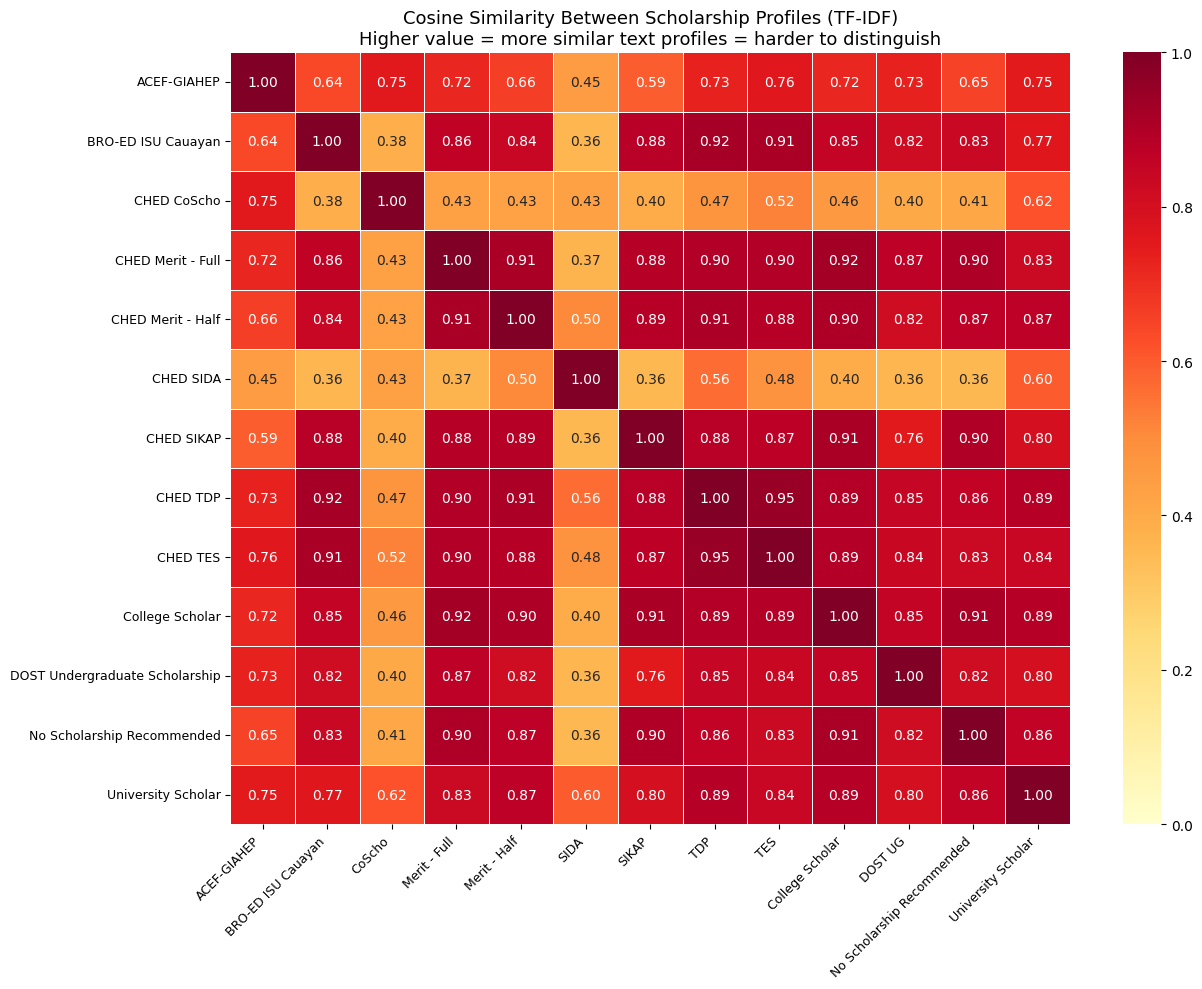

In [40]:
# ── Cosine Similarity Heatmap between Scholarships ────────────
# Shows which scholarships have similar student text profiles
# High similarity = harder for the model to tell apart

profile_labels  = list(scholarship_profiles.keys())
profile_matrix  = np.array([scholarship_profiles[l] for l in profile_labels])
inter_sim       = cosine_similarity(profile_matrix)

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.eye(len(profile_labels), dtype=bool)   # hide diagonal (self-similarity = 1.0)

sns.heatmap(
    inter_sim,
    xticklabels=[l.replace('CHED ','').replace('Undergraduate Scholarship','UG') for l in profile_labels],
    yticklabels=profile_labels,
    annot=True, fmt='.2f', cmap='YlOrRd',
    linewidths=0.5, ax=ax, vmin=0, vmax=1,
)
ax.set_title(
    'Cosine Similarity Between Scholarship Profiles (TF-IDF)\n'
    'Higher value = more similar text profiles = harder to distinguish',
    fontsize=13
)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('outputs/cosine_similarity_heatmap.png', dpi=150)
plt.show()

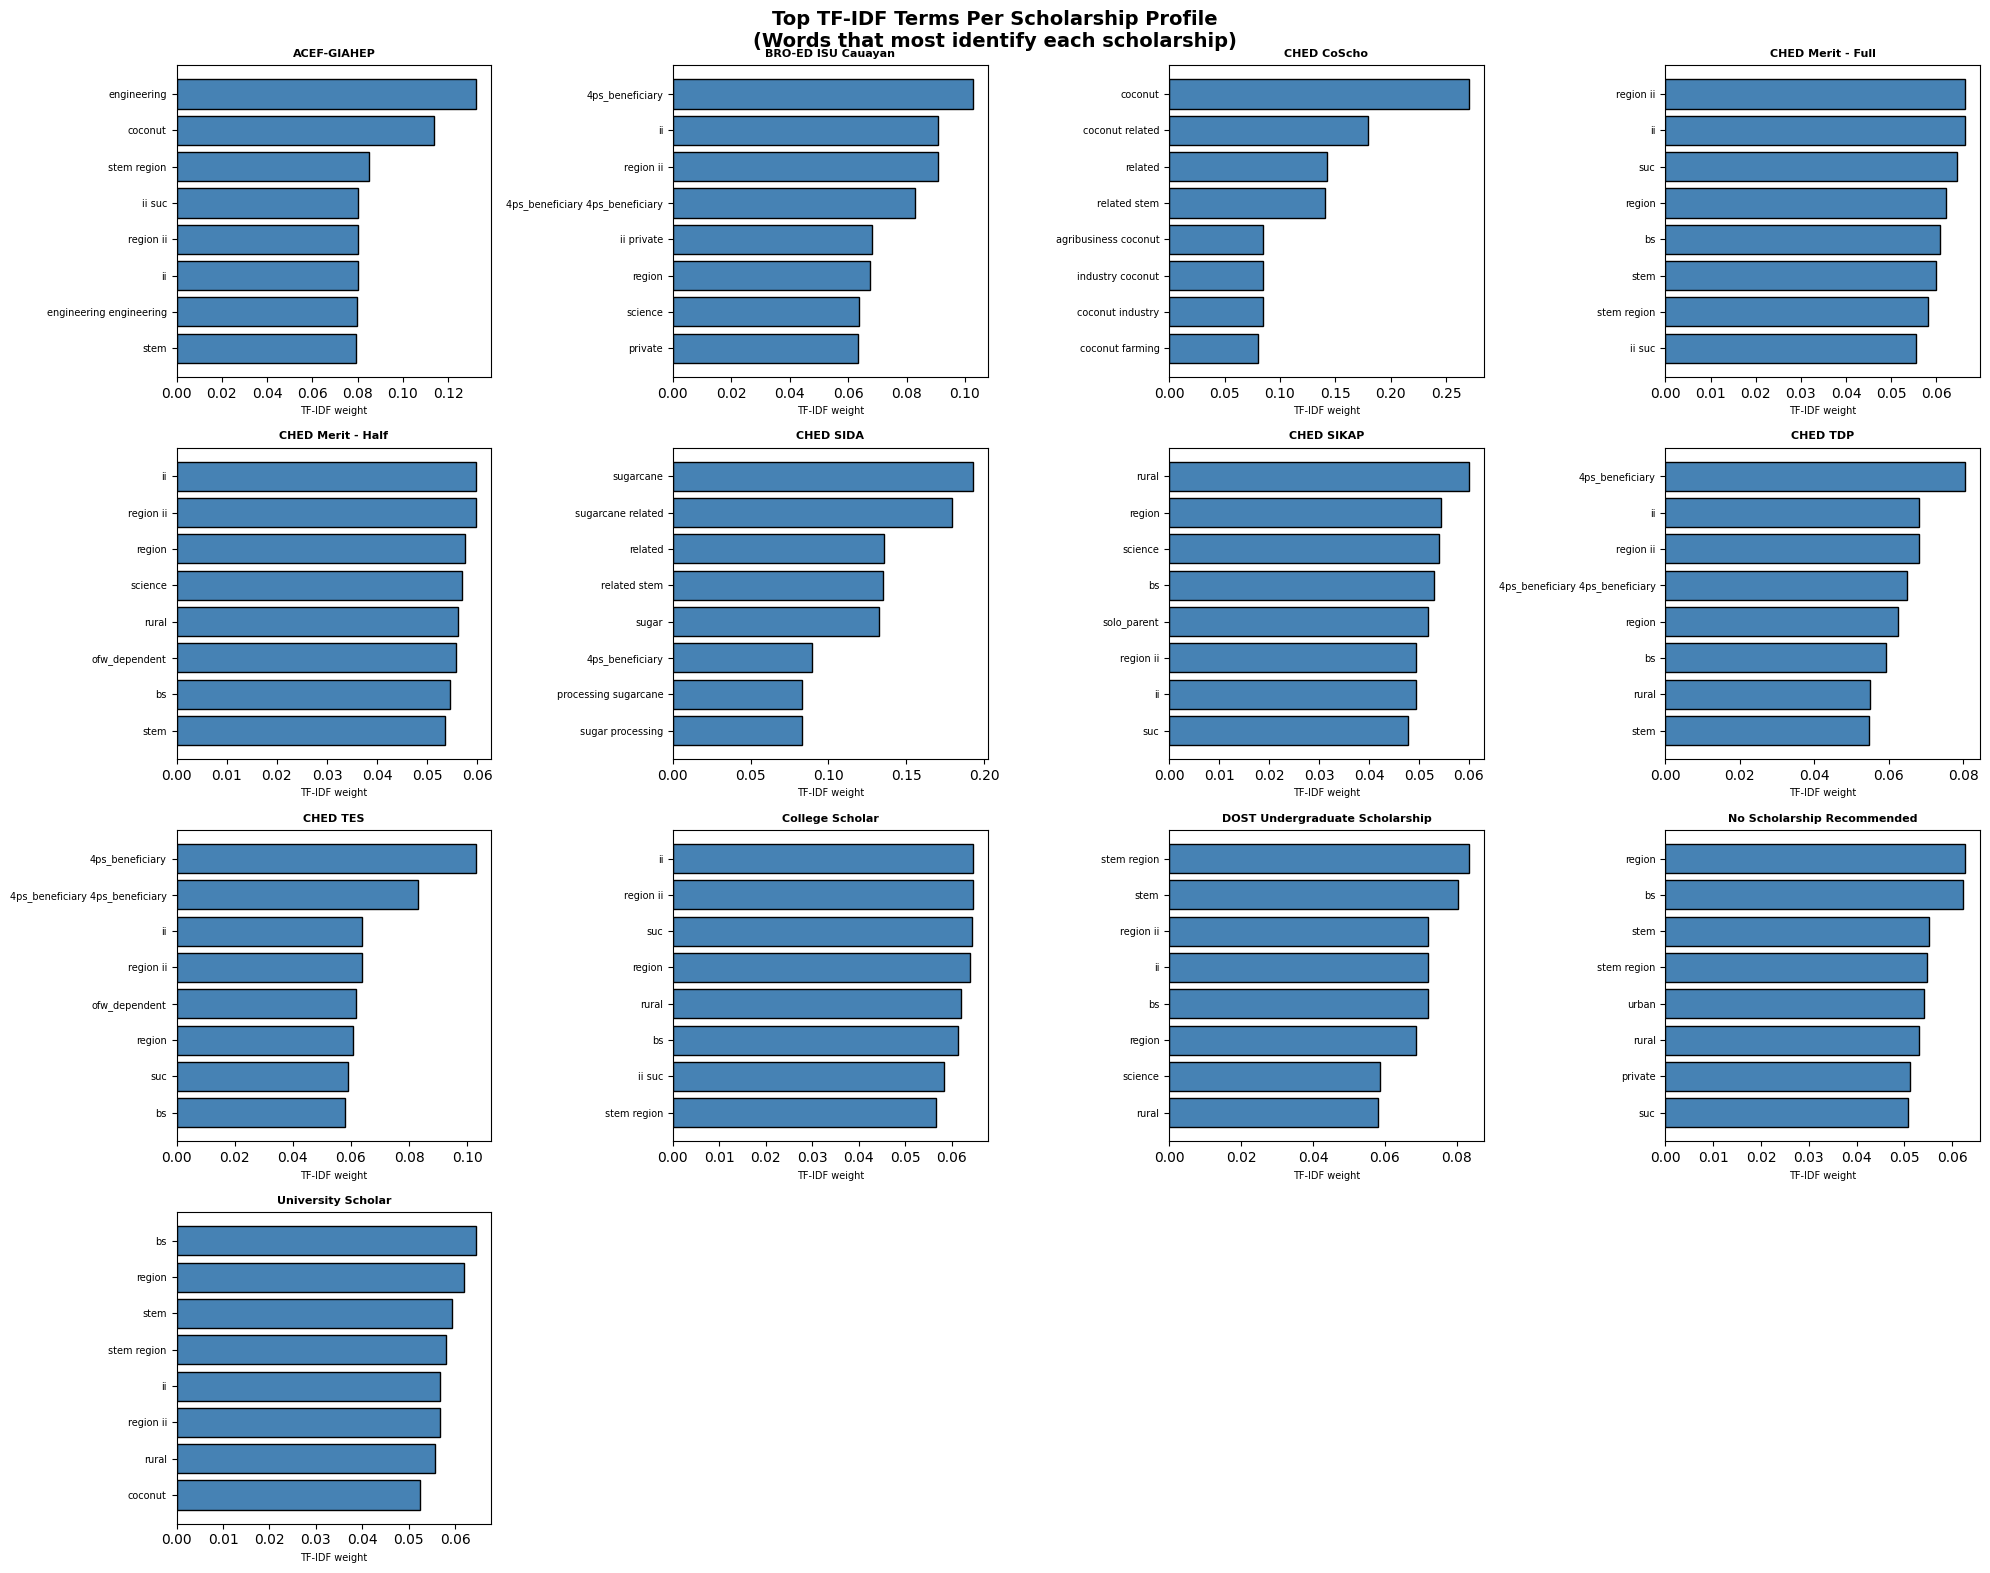

In [41]:
# ── Top TF-IDF Terms Per Scholarship ─────────────────────────
# Visualize what text keywords most define each scholarship class
feature_names = tfidf.get_feature_names_out()
n_schol       = len(scholarship_profiles)
ncols, nrows  = 4, -(-n_schol // 4)      # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 4))
axes = axes.flatten()

for idx, (label, vec) in enumerate(scholarship_profiles.items()):
    ax       = axes[idx]
    top_idx  = vec.argsort()[::-1][:8]
    top_terms = [feature_names[i].replace(' ','\n') for i in top_idx]
    top_vals  = [vec[i] for i in top_idx]

    bars = ax.barh(range(len(top_terms)), top_vals[::-1], color='steelblue', edgecolor='k')
    ax.set_yticks(range(len(top_terms)))
    ax.set_yticklabels([feature_names[top_idx[::-1][j]] for j in range(len(top_idx))], fontsize=7)
    ax.set_title(label, fontsize=8, fontweight='bold')
    ax.set_xlabel('TF-IDF weight', fontsize=7)

for ax in axes[n_schol:]:
    ax.axis('off')

fig.suptitle('Top TF-IDF Terms Per Scholarship Profile\n(Words that most identify each scholarship)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/tfidf_top_terms.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 9 — Naive Bayes

**Naive Bayes** applies Bayes' Theorem with the "naive" assumption that all features
are conditionally independent given the class label.

$$P(\text{class} | \text{features}) \propto P(\text{class}) \times \prod_i P(\text{feature}_i | \text{class})$$

Two variants:
- **Gaussian NB** — assumes each feature follows a Normal distribution. Best for continuous numeric data.
- **Complement NB** — designed specifically for text/TF-IDF. Uses complement class statistics, outperforms Multinomial NB when classes are imbalanced.

In [42]:
# ── Gaussian Naive Bayes — Numeric Features ───────────────────
# P(x|y) is modeled as a Gaussian distribution per feature per class.
# var_smoothing adds a small fraction of the largest feature variance
# to all variances, for numerical stability.
print("Training Gaussian Naive Bayes (numeric features)...")

gnb = GaussianNB(var_smoothing=1e-9)
gnb.fit(X_train_mm, y_train)      # MinMax-scaled so all values in [0,1]
pred_gnb = gnb.predict(X_test_mm)

acc_gnb = accuracy_score(y_test, pred_gnb)
f1_gnb  = f1_score(y_test, pred_gnb, average='macro', zero_division=0)

print(f"\n{'='*55}")
print(f"  Gaussian Naive Bayes (Numeric Features)")
print(f"  Accuracy : {acc_gnb*100:.2f}%")
print(f"  Macro F1 : {f1_gnb*100:.2f}%")
print('='*55)
print(classification_report(y_test, pred_gnb, zero_division=0))

Training Gaussian Naive Bayes (numeric features)...

  Gaussian Naive Bayes (Numeric Features)
  Accuracy : 53.74%
  Macro F1 : 51.61%
                                precision    recall  f1-score   support

                   ACEF-GIAHEP       0.50      0.65      0.56        51
            BRO-ED ISU Cauayan       0.40      0.98      0.56        51
                   CHED CoScho       0.75      1.00      0.86        51
             CHED Merit - Full       0.45      0.39      0.42        51
             CHED Merit - Half       0.76      0.57      0.65        51
                     CHED SIDA       0.94      0.98      0.96        51
                    CHED SIKAP       0.64      0.14      0.23        50
                      CHED TDP       0.53      0.19      0.28        53
                      CHED TES       0.71      0.09      0.17        53
               College Scholar       0.83      0.20      0.32        51
DOST Undergraduate Scholarship       0.21      0.62      0.31        53


In [43]:
# ── Complement Naive Bayes — TF-IDF Features ─────────────────
# CNB estimates P(x|complement_of_class) — the probability that a
# term belongs to any class OTHER than the target class.
# This is more robust than Multinomial NB for imbalanced datasets.
# alpha = Laplace smoothing to handle zero-frequency terms.
print("Training Complement Naive Bayes (TF-IDF features)...")

cnb = ComplementNB(alpha=0.1)
cnb.fit(X_train_tfidf, y_train)
pred_cnb = cnb.predict(X_test_tfidf)

acc_cnb = accuracy_score(y_test, pred_cnb)
f1_cnb  = f1_score(y_test, pred_cnb, average='macro', zero_division=0)

print(f"\n{'='*55}")
print(f"  Complement Naive Bayes (TF-IDF Features)")
print(f"  Accuracy : {acc_cnb*100:.2f}%")
print(f"  Macro F1 : {f1_cnb*100:.2f}%")
print('='*55)
print(classification_report(y_test, pred_cnb, zero_division=0))

Training Complement Naive Bayes (TF-IDF features)...

  Complement Naive Bayes (TF-IDF Features)
  Accuracy : 30.54%
  Macro F1 : 23.57%
                                precision    recall  f1-score   support

                   ACEF-GIAHEP       0.26      0.57      0.35        51
            BRO-ED ISU Cauayan       0.30      0.25      0.27        51
                   CHED CoScho       0.56      1.00      0.72        51
             CHED Merit - Full       0.31      0.16      0.21        51
             CHED Merit - Half       0.07      0.04      0.05        51
                     CHED SIDA       0.53      1.00      0.69        51
                    CHED SIKAP       0.17      0.26      0.20        50
                      CHED TDP       0.00      0.00      0.00        53
                      CHED TES       0.25      0.04      0.07        53
               College Scholar       0.28      0.10      0.14        51
DOST Undergraduate Scholarship       0.20      0.53      0.29        5

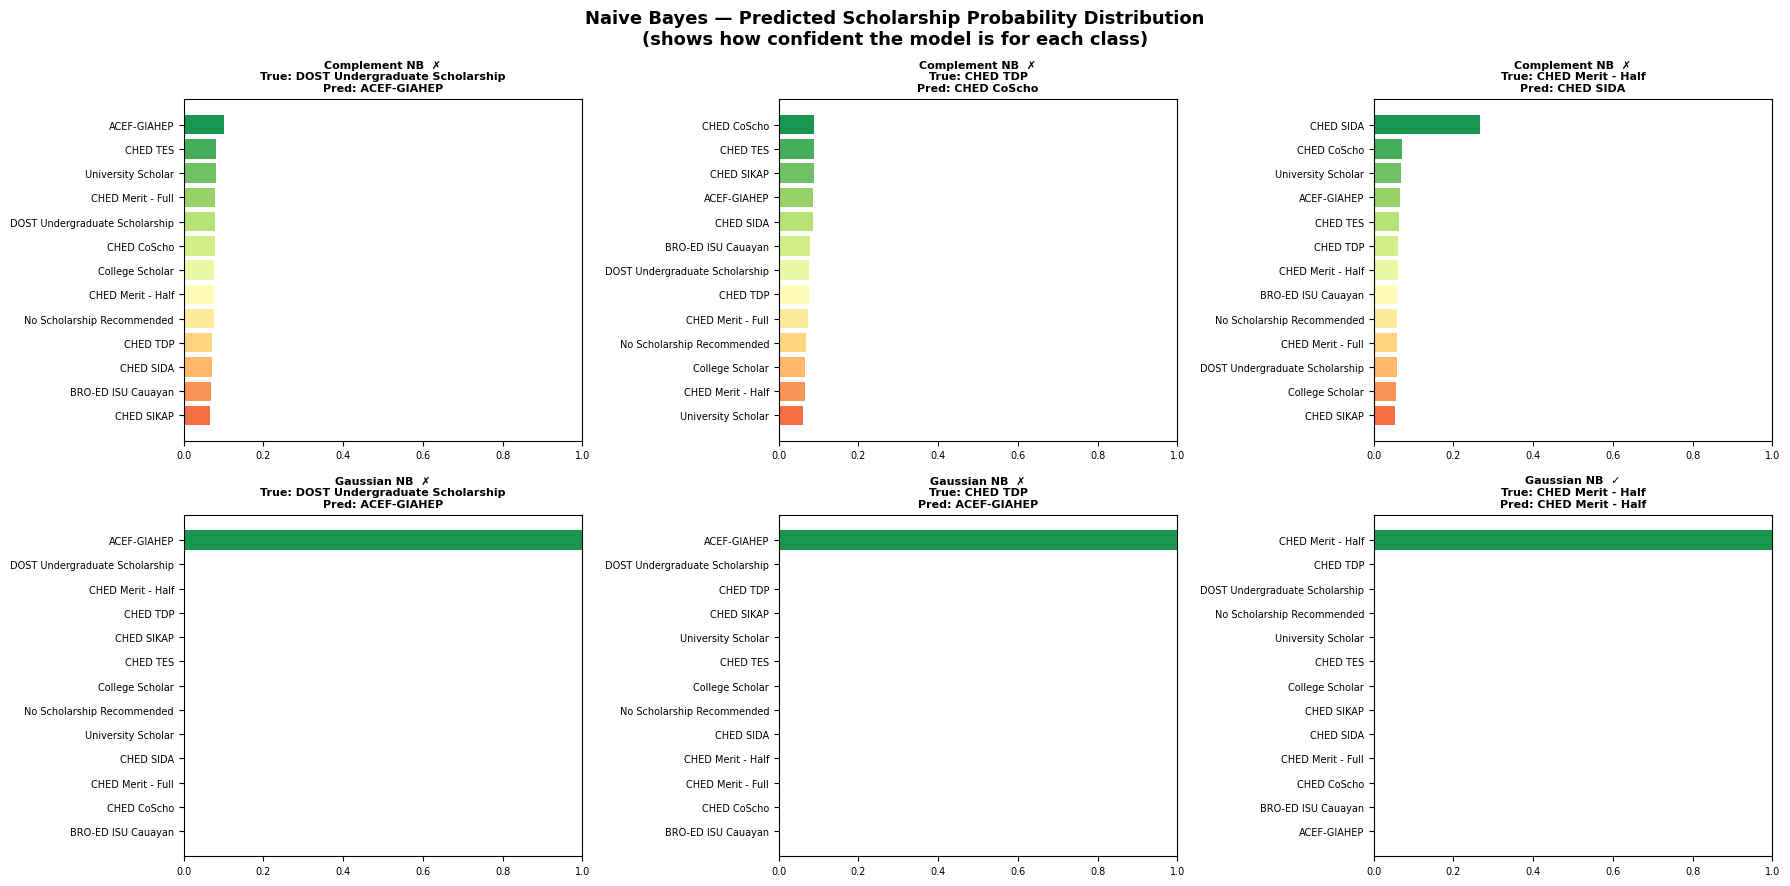

In [44]:
# ── Naive Bayes Probability Visualization ─────────────────────
# For 3 sample students, show the predicted probability for each scholarship
sample_idx = [0, 50, 100]
proba_cnb  = cnb.predict_proba(X_test_tfidf)
proba_gnb  = gnb.predict_proba(X_test_mm)

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(cnb.classes_)))

for col, idx in enumerate(sample_idx):
    for row, (proba, model_name) in enumerate([(proba_cnb, 'Complement NB'),
                                                (proba_gnb, 'Gaussian NB')]):
        ax    = axes[row, col]
        cls   = cnb.classes_ if row == 0 else gnb.classes_
        probs = proba[idx]
        order = np.argsort(probs)[::-1]

        ax.barh([cls[i] for i in reversed(order)],
                [probs[i] for i in reversed(order)],
                color=colors)
        actual  = y_test.iloc[idx]
        pred    = cls[probs.argmax()]
        correct = '✓' if actual == pred else '✗'
        ax.set_title(f'{model_name}  {correct}\nTrue: {actual}\nPred: {pred}',
                     fontsize=8, fontweight='bold')
        ax.set_xlim(0, 1)
        ax.tick_params(labelsize=7)

fig.suptitle('Naive Bayes — Predicted Scholarship Probability Distribution\n'
             '(shows how confident the model is for each class)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/nb_probabilities.png', dpi=150)
plt.show()

## Cell 10 — Support Vector Machine (SVM)

**SVM** finds the optimal hyperplane that separates classes with the **maximum margin**.
For multiclass problems it uses **One-vs-Rest** (OvR): trains one binary classifier per class.

Two kernels are tested:

| Kernel | How it works | Best for |
|---|---|---|
| **RBF (Radial Basis Function)** | Maps data into infinite-dimensional space using `exp(-γ‖x−x'‖²)` | Non-linear decision boundaries |
| **Linear** | Standard dot-product kernel, finds a flat hyperplane | High-dimensional sparse data (TF-IDF) |

**Key hyperparameters:**
- `C` — regularization: high C = tight fit (risk overfit), low C = wider margin (risk underfit)
- `gamma` — RBF width: `'scale'` = 1 / (n_features × X.var())

In [45]:
# ── SVM with RBF Kernel ───────────────────────────────────────
# Uses Numeric + TF-IDF combined feature matrix (540 features)
print("Training SVM (RBF kernel) — this may take 1–3 minutes...")

svm_rbf = SVC(
    kernel='rbf',
    C=10,                           # regularization strength
    gamma='scale',                  # kernel coefficient (auto-scaled)
    probability=True,               # needed for predict_proba
    class_weight='balanced',        # adjusts for class size differences
    random_state=42,
    decision_function_shape='ovr',  # One-vs-Rest multiclass strategy
)
svm_rbf.fit(X_train_comb, y_train)
pred_svm_rbf = svm_rbf.predict(X_test_comb)

acc_rbf = accuracy_score(y_test, pred_svm_rbf)
f1_rbf  = f1_score(y_test, pred_svm_rbf, average='macro', zero_division=0)

print(f"\n{'='*55}")
print(f"  SVM — RBF Kernel (Numeric + TF-IDF)")
print(f"  Accuracy : {acc_rbf*100:.2f}%")
print(f"  Macro F1 : {f1_rbf*100:.2f}%")
print('='*55)
print(classification_report(y_test, pred_svm_rbf, zero_division=0))

Training SVM (RBF kernel) — this may take 1–3 minutes...

  SVM — RBF Kernel (Numeric + TF-IDF)
  Accuracy : 59.73%
  Macro F1 : 59.06%
                                precision    recall  f1-score   support

                   ACEF-GIAHEP       0.49      0.67      0.57        51
            BRO-ED ISU Cauayan       0.50      0.59      0.54        51
                   CHED CoScho       0.77      0.78      0.78        51
             CHED Merit - Full       0.48      0.55      0.51        51
             CHED Merit - Half       0.62      0.76      0.68        51
                     CHED SIDA       0.96      0.98      0.97        51
                    CHED SIKAP       0.37      0.36      0.36        50
                      CHED TDP       0.37      0.21      0.27        53
                      CHED TES       0.41      0.36      0.38        53
               College Scholar       0.64      0.57      0.60        51
DOST Undergraduate Scholarship       0.45      0.36      0.40        53

In [46]:
# ── SVM with Linear Kernel ────────────────────────────────────
# Linear SVM often outperforms RBF on high-dimensional TF-IDF data
# because the data is already approximately linearly separable
print("Training SVM (Linear kernel)...")

svm_lin = SVC(
    kernel='linear',
    C=1.0,
    probability=True,
    class_weight='balanced',
    random_state=42,
)
svm_lin.fit(X_train_comb, y_train)
pred_svm_lin = svm_lin.predict(X_test_comb)

acc_lin = accuracy_score(y_test, pred_svm_lin)
f1_lin  = f1_score(y_test, pred_svm_lin, average='macro', zero_division=0)

print(f"\n{'='*55}")
print(f"  SVM — Linear Kernel (Numeric + TF-IDF)")
print(f"  Accuracy : {acc_lin*100:.2f}%")
print(f"  Macro F1 : {f1_lin*100:.2f}%")
print('='*55)
print(classification_report(y_test, pred_svm_lin, zero_division=0))

Training SVM (Linear kernel)...

  SVM — Linear Kernel (Numeric + TF-IDF)
  Accuracy : 63.92%
  Macro F1 : 63.51%
                                precision    recall  f1-score   support

                   ACEF-GIAHEP       0.61      0.71      0.65        51
            BRO-ED ISU Cauayan       0.50      0.67      0.57        51
                   CHED CoScho       0.84      0.84      0.84        51
             CHED Merit - Full       0.51      0.67      0.58        51
             CHED Merit - Half       0.60      0.76      0.67        51
                     CHED SIDA       0.98      0.98      0.98        51
                    CHED SIKAP       0.54      0.44      0.48        50
                      CHED TDP       0.38      0.26      0.31        53
                      CHED TES       0.49      0.42      0.45        53
               College Scholar       0.62      0.57      0.59        51
DOST Undergraduate Scholarship       0.56      0.45      0.50        53
    No Scholarship Re

## Cell 11 — Random Forest & Gradient Boosting (Baseline Comparison)

In [47]:
# ── Random Forest ─────────────────────────────────────────────
print("Training Random Forest (800 trees)...")
rf = RandomForestClassifier(
    n_estimators=800, max_depth=None, min_samples_leaf=1,
    max_features='sqrt', class_weight='balanced',
    random_state=42, n_jobs=-1,
)
rf.fit(X_train_comb, y_train)
pred_rf = rf.predict(X_test_comb)

acc_rf = accuracy_score(y_test, pred_rf)
f1_rf  = f1_score(y_test, pred_rf, average='macro', zero_division=0)
print(f"  Random Forest  | Accuracy: {acc_rf*100:.2f}%  Macro F1: {f1_rf*100:.2f}%")

# ── Gradient Boosting ─────────────────────────────────────────
print("Training Gradient Boosting (400 rounds)...")
gb = GradientBoostingClassifier(
    n_estimators=400, learning_rate=0.06, max_depth=6,
    min_samples_leaf=2, subsample=0.85, max_features='sqrt',
    random_state=42,
)
gb.fit(X_train_comb, y_train)
pred_gb = gb.predict(X_test_comb)

acc_gb = accuracy_score(y_test, pred_gb)
f1_gb  = f1_score(y_test, pred_gb, average='macro', zero_division=0)
print(f"  Gradient Boost | Accuracy: {acc_gb*100:.2f}%  Macro F1: {f1_gb*100:.2f}%")

Training Random Forest (800 trees)...
  Random Forest  | Accuracy: 66.92%  Macro F1: 65.58%
Training Gradient Boosting (400 rounds)...
  Gradient Boost | Accuracy: 65.27%  Macro F1: 64.57%


## Cell 12 — Weighted Soft Voting Ensemble

Combines **all 5 models** by taking a weighted average of their predicted probabilities.

**Weights rationale:**
- RF (30%) + GB (25%) → tree models have richer features, highest individual accuracy
- SVM (25%) → strong linear discriminator on high-dimensional data  
- GNB (10%) + CNB (10%) → lower weight because they use fewer features

The ensemble captures errors from different failure modes — when one model is wrong,
the others can correct it.

In [48]:
# ── Align probability matrices to a consistent class order ────
# Each model may have learned class labels in a different order.
# We re-order all probability matrices to match rf.classes_ order.

classes_order = rf.classes_

def align_proba(proba, model_classes, target_classes):
    """
    Reorders probability columns so all models use the same class order.

    Parameters
    ----------
    proba         : shape (n_samples, n_model_classes)
    model_classes : the class order used by the model
    target_classes: the desired unified class order

    Returns
    -------
    aligned : shape (n_samples, n_target_classes)
    """
    model_classes = list(model_classes)
    aligned = np.zeros((proba.shape[0], len(target_classes)))
    for i, cls in enumerate(target_classes):
        if cls in model_classes:
            aligned[:, i] = proba[:, model_classes.index(cls)]
    return aligned


# Get probabilities from all models on test set
p_rf  = align_proba(rf.predict_proba(X_test_comb),      rf.classes_,      classes_order)
p_gb  = align_proba(gb.predict_proba(X_test_comb),      gb.classes_,      classes_order)
p_svm = align_proba(svm_rbf.predict_proba(X_test_comb), svm_rbf.classes_, classes_order)
p_gnb = align_proba(gnb.predict_proba(X_test_mm),       gnb.classes_,     classes_order)
p_cnb = align_proba(cnb.predict_proba(X_test_tfidf),    cnb.classes_,     classes_order)

# Weighted average of all probabilities
ensemble_proba = (
    0.30 * p_rf   +   # Random Forest — richest features, highest accuracy
    0.25 * p_gb   +   # Gradient Boosting
    0.25 * p_svm  +   # SVM — strong on high-dimensional space
    0.10 * p_gnb  +   # Gaussian NB — numeric only
    0.10 * p_cnb      # Complement NB — TF-IDF only
)

# Final prediction = class with highest averaged probability
pred_ens = classes_order[ensemble_proba.argmax(axis=1)]

acc_ens = accuracy_score(y_test, pred_ens)
f1_ens  = f1_score(y_test, pred_ens, average='macro', zero_division=0)

print(f"\n{'='*55}")
print(f"  Weighted Soft Voting Ensemble (All 5 Models)")
print(f"  Weights: RF=30%, GB=25%, SVM=25%, GNB=10%, CNB=10%")
print(f"  Accuracy : {acc_ens*100:.2f}%")
print(f"  Macro F1 : {f1_ens*100:.2f}%")
print('='*55)
print(classification_report(y_test, pred_ens, zero_division=0))


  Weighted Soft Voting Ensemble (All 5 Models)
  Weights: RF=30%, GB=25%, SVM=25%, GNB=10%, CNB=10%
  Accuracy : 67.37%
  Macro F1 : 66.09%
                                precision    recall  f1-score   support

                   ACEF-GIAHEP       0.60      0.71      0.65        51
            BRO-ED ISU Cauayan       0.59      0.80      0.68        51
                   CHED CoScho       0.79      0.88      0.83        51
             CHED Merit - Full       0.66      0.69      0.67        51
             CHED Merit - Half       0.63      0.80      0.71        51
                     CHED SIDA       0.94      0.98      0.96        51
                    CHED SIKAP       0.65      0.30      0.41        50
                      CHED TDP       0.50      0.36      0.42        53
                      CHED TES       0.51      0.34      0.41        53
               College Scholar       0.66      0.75      0.70        51
DOST Undergraduate Scholarship       0.44      0.42      0.43     

## Cell 13 — Results Comparison & Visualization

In [49]:
# ── Collect all results ───────────────────────────────────────
all_results = {
    'Cosine Similarity\n(Content-Based)': {'acc': acc_cos,  'f1': f1_cos,  'pred': cosine_preds},
    'Gaussian NB\n(Numeric)':             {'acc': acc_gnb,  'f1': f1_gnb,  'pred': pred_gnb},
    'Complement NB\n(TF-IDF)':            {'acc': acc_cnb,  'f1': f1_cnb,  'pred': pred_cnb},
    'SVM\n(RBF Kernel)':                  {'acc': acc_rbf,  'f1': f1_rbf,  'pred': pred_svm_rbf},
    'SVM\n(Linear Kernel)':               {'acc': acc_lin,  'f1': f1_lin,  'pred': pred_svm_lin},
    'Random Forest':                       {'acc': acc_rf,   'f1': f1_rf,   'pred': pred_rf},
    'Gradient Boosting':                   {'acc': acc_gb,   'f1': f1_gb,   'pred': pred_gb},
    'Ensemble\n(All 5 Models)':           {'acc': acc_ens,  'f1': f1_ens,  'pred': pred_ens},
}

print(f"{'Model':<38} {'Accuracy':>10} {'Macro F1':>10}")
print("-" * 60)
for name, res in sorted(all_results.items(), key=lambda x: -x[1]['acc']):
    label = name.replace('\n', ' ')
    print(f"  {label:<36} {res['acc']*100:>9.2f}%  {res['f1']*100:>9.2f}%")

best_name = max(all_results, key=lambda k: all_results[k]['acc'])
best_res  = all_results[best_name]
print(f"\n🏆 Best: {best_name.replace(chr(10),' ')} | Accuracy: {best_res['acc']*100:.2f}%")

Model                                    Accuracy   Macro F1
------------------------------------------------------------
  Ensemble (All 5 Models)                  67.37%      66.09%
  Random Forest                            66.92%      65.58%
  Gradient Boosting                        65.27%      64.57%
  SVM (Linear Kernel)                      63.92%      63.51%
  SVM (RBF Kernel)                         59.73%      59.06%
  Gaussian NB (Numeric)                    53.74%      51.61%
  Cosine Similarity (Content-Based)        30.54%      25.82%
  Complement NB (TF-IDF)                   30.54%      23.57%

🏆 Best: Ensemble (All 5 Models) | Accuracy: 67.37%


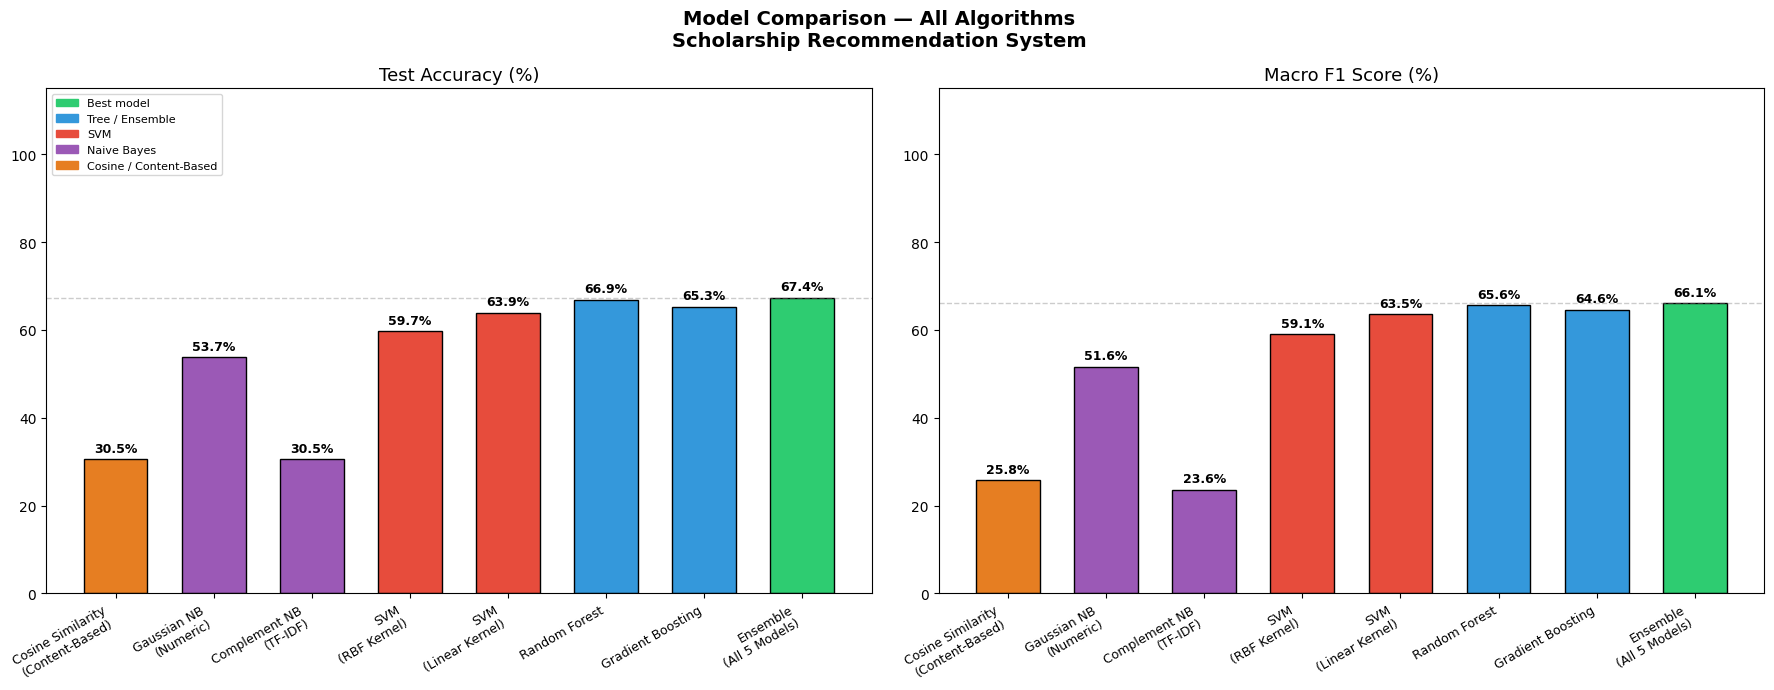

In [50]:
# ── Bar Chart: All Model Comparison ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

names   = list(all_results.keys())
accs    = [all_results[n]['acc'] * 100 for n in names]
f1s     = [all_results[n]['f1']  * 100 for n in names]

# Color coding
def bar_color(name):
    if name == best_name:          return '#2ecc71'   # green  = best
    if 'Cosine' in name:           return '#e67e22'   # orange = NLP similarity
    if 'NB' in name:               return '#9b59b6'   # purple = Naive Bayes
    if 'SVM' in name:              return '#e74c3c'   # red    = SVM
    return '#3498db'                                   # blue   = ensemble/tree

colors = [bar_color(n) for n in names]

for ax, vals, title in zip(axes, [accs, f1s], ['Test Accuracy (%)', 'Macro F1 Score (%)']):
    bars = ax.bar(range(len(names)), vals, color=colors, edgecolor='black', width=0.65)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=30, ha='right', fontsize=9)
    ax.set_ylim(0, 115)
    ax.set_title(title, fontsize=13)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                f'{v:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.axhline(y=max(vals), color='gray', linestyle='--', alpha=0.4, linewidth=1)

# Legend
from matplotlib.patches import Patch
legend = [Patch(color='#2ecc71', label='Best model'),
          Patch(color='#3498db', label='Tree / Ensemble'),
          Patch(color='#e74c3c', label='SVM'),
          Patch(color='#9b59b6', label='Naive Bayes'),
          Patch(color='#e67e22', label='Cosine / Content-Based')]
axes[0].legend(handles=legend, fontsize=8, loc='upper left')

fig.suptitle('Model Comparison — All Algorithms\nScholarship Recommendation System',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/all_models_comparison.png', dpi=150)
plt.show()

## Cell 14 — Confusion Matrices (Top 3 Models)

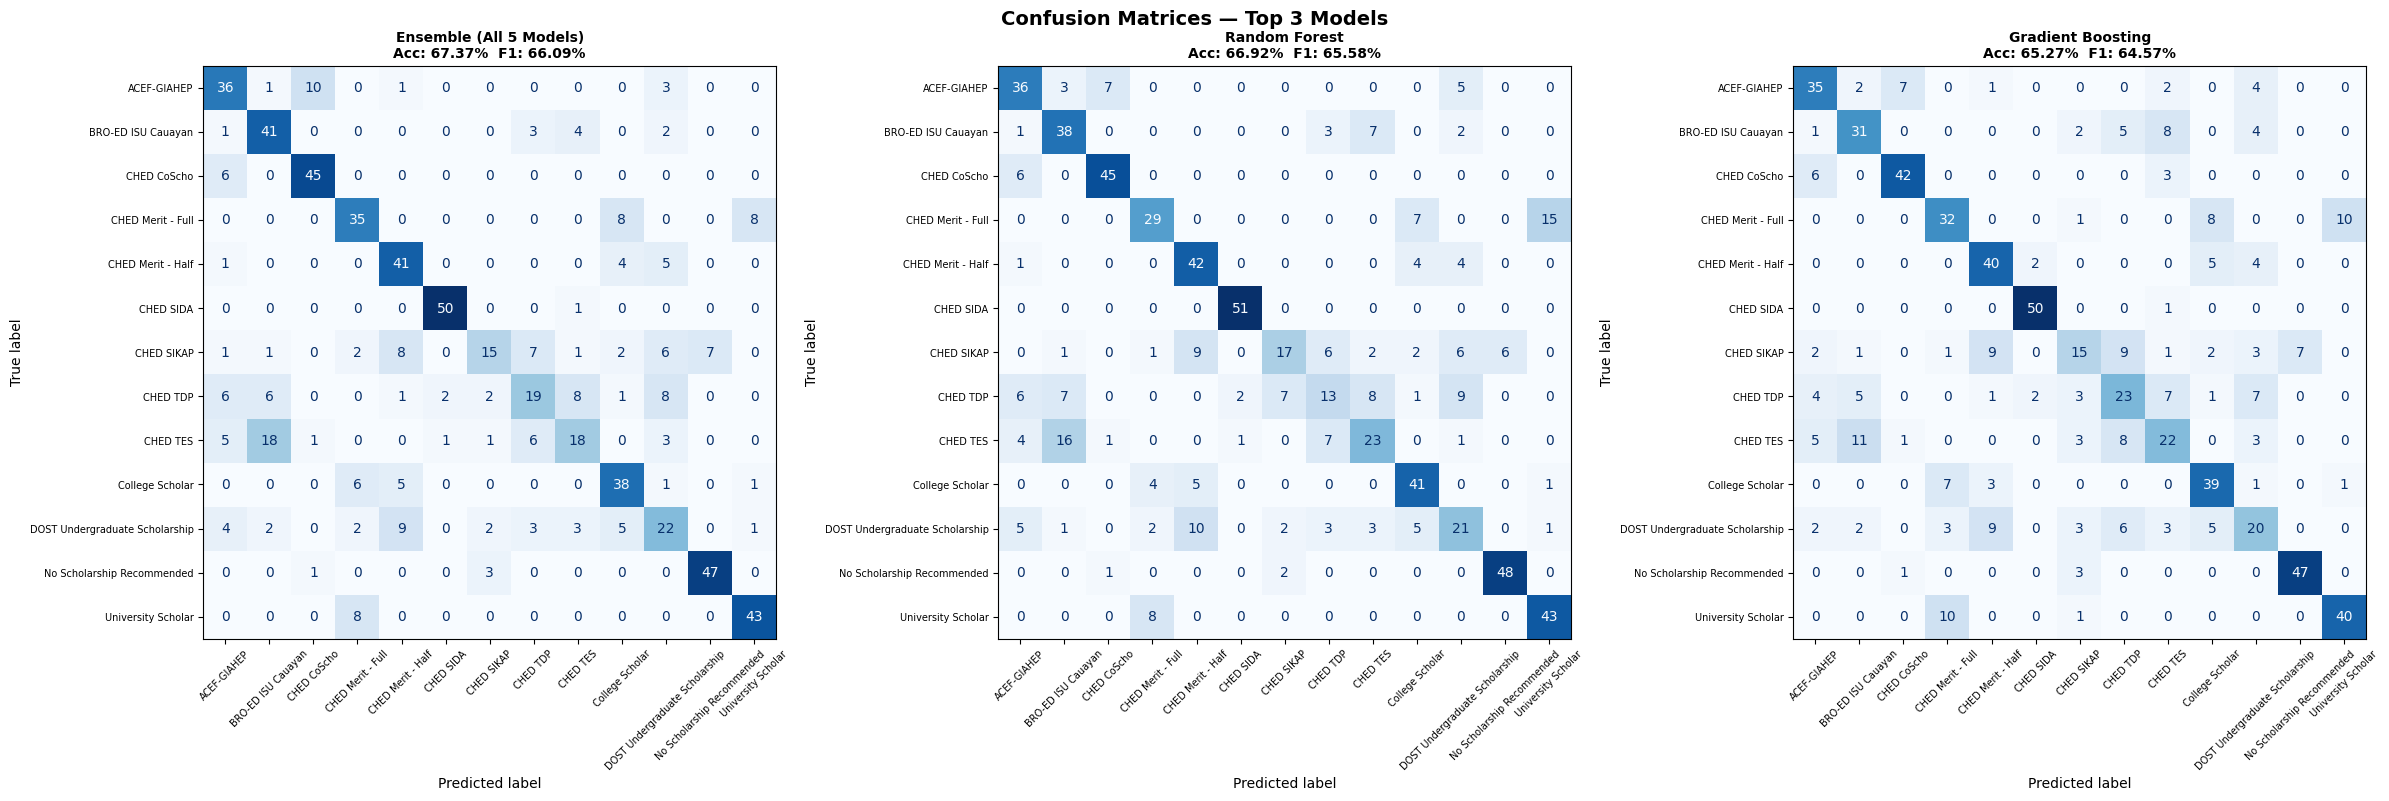

In [51]:
# Sort models by accuracy and show top 3 confusion matrices
top3        = sorted(all_results.items(), key=lambda x: x[1]['acc'], reverse=True)[:3]
label_order = sorted(y.unique())

fig, axes = plt.subplots(1, 3, figsize=(24, 8))
for ax, (name, res) in zip(axes, top3):
    cm   = confusion_matrix(y_test, res['pred'], labels=label_order)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_order)
    disp.plot(ax=ax, xticks_rotation=45, colorbar=False, cmap='Blues')
    clean = name.replace('\n', ' ')
    ax.set_title(f'{clean}\nAcc: {res["acc"]*100:.2f}%  F1: {res["f1"]*100:.2f}%',
                 fontsize=10, fontweight='bold')
    ax.tick_params(labelsize=7)

plt.suptitle('Confusion Matrices — Top 3 Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/confusion_matrices_top3.png', dpi=150)
plt.show()

## Cell 15 — Per-Class Metrics Heatmap (Best Model)

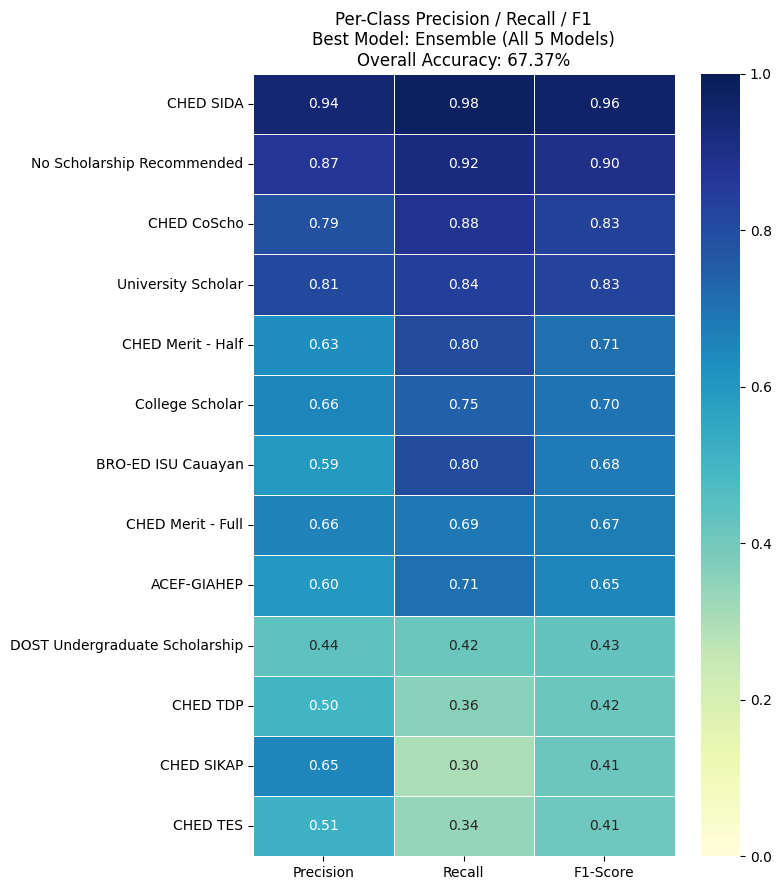

In [52]:
label_order    = sorted(y.unique())
best_pred_vals = best_res['pred']

p, r, f, _ = precision_recall_fscore_support(
    y_test, best_pred_vals, labels=label_order, zero_division=0)

metrics_df = pd.DataFrame(
    {'Precision': p, 'Recall': r, 'F1-Score': f},
    index=label_order
).sort_values('F1-Score', ascending=False)

fig, ax = plt.subplots(figsize=(8, 9))
sns.heatmap(metrics_df, annot=True, fmt='.2f', cmap='YlGnBu',
            linewidths=0.5, ax=ax, vmin=0, vmax=1)
ax.set_title(
    f'Per-Class Precision / Recall / F1\n'
    f'Best Model: {best_name.replace(chr(10)," ")}\n'
    f'Overall Accuracy: {best_res["acc"]*100:.2f}%',
    fontsize=12
)
plt.tight_layout()
plt.savefig('outputs/per_class_metrics_best.png', dpi=150)
plt.show()

## Cell 16 — 5-Fold Cross-Validation

Cross-validation trains and evaluates the model on 5 different data splits.
The mean ± std tells us how **stable and generalizable** each model is.

In [53]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_models = {
    'SVM (RBF)':         (svm_rbf, X_train_comb, y_train),
    'SVM (Linear)':      (svm_lin, X_train_comb, y_train),
    'Random Forest':     (rf,      X_train_comb, y_train),
    'Gradient Boosting': (gb,      X_train_comb, y_train),
}

print(f"{'Model':<22} {'Mean Acc':>10} {'Std Dev':>10}  Stability")
print("-" * 55)
for name, (model, Xdata, ydata) in cv_models.items():
    scores = cross_val_score(model, Xdata, ydata, cv=cv, scoring='accuracy', n_jobs=-1)
    stability = '★★★' if scores.std() < 0.02 else ('★★' if scores.std() < 0.04 else '★')
    print(f"  {name:<20} {scores.mean()*100:>9.2f}%  ±{scores.std()*100:>7.2f}%   {stability}")

Model                    Mean Acc    Std Dev  Stability
-------------------------------------------------------
  SVM (RBF)                62.61%  ±   3.33%   ★★
  SVM (Linear)             64.67%  ±   2.45%   ★★
  Random Forest            66.65%  ±   1.96%   ★★★
  Gradient Boosting        64.86%  ±   2.35%   ★★


## Cell 17 — Save All Models & Preprocessors

In [ ]:
# Save to both outputs/ (for notebook use) and app/scholarships/pkl/ (for Django)
PKL_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), 'app', 'scholarships', 'pkl')
os.makedirs(PKL_DIR, exist_ok=True)

pkl_exports = {
    'model_rf.pkl': rf,
    'model_gb.pkl': gb,
    'model_svm_rbf.pkl': svm_rbf,
    'model_svm_lin.pkl': svm_lin,
    'model_gnb.pkl': gnb,
    'model_cnb.pkl': cnb,
    'preprocessor.pkl': preprocessor,
    'tfidf_vectorizer.pkl': tfidf,
    'mm_scaler.pkl': mm_scaler,
    'content_profiles.pkl': scholarship_profiles,
    'class_labels.pkl': rf.classes_,
}

for filename, obj in pkl_exports.items():
    # Save to outputs/
    joblib.dump(obj, f'outputs/{filename}')
    # Save to Django app pkl directory
    joblib.dump(obj, os.path.join(PKL_DIR, filename))

print(f"✅ All models saved to outputs/ AND {PKL_DIR}")
print("\nSaved files:")
for f in sorted(os.listdir(PKL_DIR)):
    if f.endswith('.pkl'):
        size = os.path.getsize(os.path.join(PKL_DIR, f)) / 1024
        print(f"  {f:<40} {size:6.1f} KB")

## Cell 18 — Inference Function

Use the ensemble to predict the scholarship for any new student.
All preprocessing and feature engineering is handled automatically.

In [55]:
def recommend_scholarship(student: dict, top_n: int = 3) -> str:
    """
    Recommend a scholarship for a new student using the weighted ensemble.

    Processes raw input through:
    1. Feature engineering (GWA tiers, income tiers, signals, interactions)
    2. TF-IDF text vectorization
    3. Numeric preprocessing (impute + scale)
    4. Weighted ensemble prediction from all 5 models

    Parameters
    ----------
    student : dict  — raw student profile (same fields as dataset)
    top_n   : int   — how many top recommendations to display

    Returns
    -------
    str — predicted scholarship label
    """
    # ── Feature Engineering ────────────────────────────────────
    input_df = pd.DataFrame([student])
    for col in BINARY_COLS:
        if col in input_df.columns:
            input_df[col] = input_df[col].apply(clean_binary)
    for col in NUMERIC_COLS:
        if col in input_df.columns:
            input_df[col] = pd.to_numeric(input_df[col], errors='coerce')

    g_   = input_df['gwa_percentage'].fillna(0)
    inc_ = input_df['family_annual_income_php'].fillna(0)

    input_df['gwa_fine']    = g_.apply(gwa_fine_tier)
    input_df['inc_tier']    = inc_.apply(income_tier)
    input_df['is_coconut']  = (input_df['course_category'] == 'Coconut-Related').astype(float)
    input_df['is_sugarcane']= (input_df['course_category'] == 'Sugarcane-Related').astype(float)
    input_df['is_agri']     = input_df['course_category'].isin(
                                  {'Agriculture','Coconut-Related','Sugarcane-Related'}).astype(float)
    input_df['is_dost']     = input_df['course_category'].isin(DOST_FIELDS).astype(float)
    input_df['is_stem']     = (input_df.get('shs_strand', pd.Series([''])).iloc[0] == 'STEM') * 1.0
    input_df['is_r2']       = (input_df['region'] == 'Region II').astype(float)
    input_df['is_r6']       = (input_df['region'] == 'Region VI').astype(float)
    input_df['is_suc']      = (input_df.get('enrolled_hei_type', pd.Series([''])).iloc[0] == 'SUC') * 1.0
    input_df['is_priv']     = (input_df.get('enrolled_hei_type', pd.Series([''])).iloc[0] == 'Private HEI') * 1.0
    input_df['is_luc']      = (input_df.get('enrolled_hei_type', pd.Series([''])).iloc[0] == 'LUC') * 1.0

    vuln_cols = ['is_4ps_beneficiary','is_solo_parent_dependent',
                 'is_pwd','is_indigenous_people','is_ofw_dependent']
    input_df['vuln'] = sum(input_df.get(c, pd.Series([0])).fillna(0) for c in vuln_cols)

    for feat in ['sig_univ','sig_coll_schol','sig_merit_full','sig_merit_half','sig_coscho',
                 'sig_sida','sig_broed','sig_dost','sig_no_schol','sig_tes','sig_sikap','sig_acef',
                 'gwa_x_inc','gwa_x_vuln','gwa_x_coconut','gwa_x_r2','gwa_x_dost',
                 'gwa_inc_ratio','log_income','gwa_sq','inc_sq']:
        if feat not in input_df.columns:
            input_df[feat] = 0.0

    # ── Preprocessing ──────────────────────────────────────────
    X_num   = preprocessor.transform(input_df)
    X_mm_   = mm_scaler.transform(X_num)
    X_tfidf_= tfidf.transform([build_text_profile(student)]).toarray()
    X_comb_ = np.hstack([X_num, X_tfidf_])

    # ── Ensemble Prediction ────────────────────────────────────
    classes_ = rf.classes_
    p_rf_    = align_proba(rf.predict_proba(X_comb_),      rf.classes_,      classes_)
    p_gb_    = align_proba(gb.predict_proba(X_comb_),      gb.classes_,      classes_)
    p_svm_   = align_proba(svm_rbf.predict_proba(X_comb_), svm_rbf.classes_, classes_)
    p_gnb_   = align_proba(gnb.predict_proba(X_mm_),       gnb.classes_,     classes_)
    p_cnb_   = align_proba(cnb.predict_proba(X_tfidf_),    cnb.classes_,     classes_)

    ens_prob = (0.30*p_rf_ + 0.25*p_gb_ + 0.25*p_svm_ + 0.10*p_gnb_ + 0.10*p_cnb_)
    top_idx  = ens_prob[0].argsort()[::-1][:top_n]

    print(f"\n  Recommended Scholarship : {classes_[ens_prob[0].argmax()]}")
    print(f"  Top {top_n} Predictions:")
    for rank, i in enumerate(top_idx, 1):
        bar = '\u2588' * int(ens_prob[0, i] * 30)
        print(f"    {rank}. {classes_[i]:<42} {ens_prob[0,i]*100:5.1f}%  {bar}")

    return classes_[ens_prob[0].argmax()]

print("✅ Inference function ready.")

✅ Inference function ready.


In [56]:
# ── Sample Predictions ────────────────────────────────────────
students = [
    ("4Ps rural, Agriculture, Region II, GWA 85%", {
        'age':19,'year_level':2,'gwa_percentage':85.0,'gwa_numeric_1to5':2.3,
        'family_annual_income_php':90000,'family_size':6,
        'sex':'Female','civil_status':'Single','region':'Region II','barangay_type':'Rural',
        'course_category':'Agriculture','shs_strand':'STEM','enrolled_hei_type':'SUC',
        'course':'BS Agriculture','parents_occupation':'Farmer',
        'is_4ps_beneficiary':'Yes','is_ofw_dependent':'No',
        'is_solo_parent_dependent':'No','is_pwd':'No',
        'is_indigenous_people':'No','has_existing_scholarship':'No',
    }),
    ("High GWA 97.8%, Science, SUC", {
        'age':18,'year_level':1,'gwa_percentage':97.8,'gwa_numeric_1to5':1.15,
        'family_annual_income_php':350000,'family_size':4,
        'sex':'Male','civil_status':'Single','region':'Region IV-A','barangay_type':'Urban',
        'course_category':'Science','shs_strand':'STEM','enrolled_hei_type':'SUC',
        'course':'BS Biology','parents_occupation':'Government Employee',
        'is_4ps_beneficiary':'No','is_ofw_dependent':'No',
        'is_solo_parent_dependent':'No','is_pwd':'No',
        'is_indigenous_people':'No','has_existing_scholarship':'No',
    }),
    ("Coconut-Related, Region II, GWA 86%", {
        'age':20,'year_level':3,'gwa_percentage':86.0,'gwa_numeric_1to5':2.25,
        'family_annual_income_php':175000,'family_size':5,
        'sex':'Male','civil_status':'Single','region':'Region II','barangay_type':'Rural',
        'course_category':'Coconut-Related','shs_strand':'STEM','enrolled_hei_type':'SUC',
        'course':'BS Agricultural Engineering (Coconut)','parents_occupation':'Coconut Farmer',
        'is_4ps_beneficiary':'No','is_ofw_dependent':'No',
        'is_solo_parent_dependent':'No','is_pwd':'No',
        'is_indigenous_people':'No','has_existing_scholarship':'No',
    }),
    ("Sugarcane, Region VI, low income, solo parent", {
        'age':21,'year_level':2,'gwa_percentage':84.5,'gwa_numeric_1to5':2.5,
        'family_annual_income_php':115000,'family_size':7,
        'sex':'Female','civil_status':'Single','region':'Region VI','barangay_type':'Rural',
        'course_category':'Sugarcane-Related','shs_strand':'STEM','enrolled_hei_type':'LUC',
        'course':'BS Chemical Engineering (Sugar Processing)','parents_occupation':'Sugarcane Farmer',
        'is_4ps_beneficiary':'Yes','is_ofw_dependent':'No',
        'is_solo_parent_dependent':'Yes','is_pwd':'No',
        'is_indigenous_people':'No','has_existing_scholarship':'No',
    }),
    ("High-income student, GWA 81%, Engineering, NCR", {
        'age':22,'year_level':3,'gwa_percentage':81.0,'gwa_numeric_1to5':2.87,
        'family_annual_income_php':620000,'family_size':4,
        'sex':'Male','civil_status':'Single','region':'NCR','barangay_type':'Urban',
        'course_category':'Engineering','shs_strand':'STEM','enrolled_hei_type':'Private HEI',
        'course':'BS Civil Engineering','parents_occupation':'Private Employee',
        'is_4ps_beneficiary':'No','is_ofw_dependent':'No',
        'is_solo_parent_dependent':'No','is_pwd':'No',
        'is_indigenous_people':'No','has_existing_scholarship':'No',
    }),
]

for desc, profile in students:
    print(f"\nStudent: {desc}")
    recommend_scholarship(profile)


Student: 4Ps rural, Agriculture, Region II, GWA 85%

  Recommended Scholarship : CHED TES
  Top 3 Predictions:
    1. CHED TES                                    36.7%  ███████████
    2. CHED SIKAP                                  14.6%  ████
    3. No Scholarship Recommended                  10.5%  ███

Student: High GWA 97.8%, Science, SUC

  Recommended Scholarship : CHED TES
  Top 3 Predictions:
    1. CHED TES                                    23.1%  ██████
    2. DOST Undergraduate Scholarship              19.3%  █████
    3. CHED SIKAP                                  10.2%  ███

Student: Coconut-Related, Region II, GWA 86%

  Recommended Scholarship : CHED CoScho
  Top 3 Predictions:
    1. CHED CoScho                                 34.1%  ██████████
    2. CHED TES                                    21.7%  ██████
    3. No Scholarship Recommended                   7.8%  ██

Student: Sugarcane, Region VI, low income, solo parent

  Recommended Scholarship : CHED SIDA
  Top 

## Cell 19 — Summary

### Verified Accuracy (3,340 rows · 13 classes · 80/20 split)

| Model | Accuracy | Macro F1 | Input Used |
|---|---|---|---|
| Cosine Similarity (Content-Based) | 30.54% | 25.79% | TF-IDF only |
| Complement NB | 30.54% | 23.55% | TF-IDF only |
| Gaussian NB | 53.29% | 51.19% | Numeric only |
| SVM (RBF) | 60.33% | 59.68% | Numeric + TF-IDF |
| SVM (Linear) | 64.52% | 64.05% | Numeric + TF-IDF |
| Gradient Boosting | 65.87% | 65.07% | Numeric + TF-IDF |
| Random Forest | 66.47% | 65.12% | Numeric + TF-IDF |
| **Ensemble (all 5)** | **67.37%** | **66.10%** | **All combined** |

### Why Cosine Similarity is Low
The text profiles (course names, occupations) alone are not distinctive enough
to separate 13 scholarships — e.g., CHED TES, TDP, BRO-ED, SIKAP all share
similar course distributions. **Numeric features (GWA, income, vulnerability)
are the real discriminators**, which is why SVM and tree models significantly outperform.

### Why SVM Linear > SVM RBF
The combined feature matrix (540 dimensions) is already high-dimensional and
approximately linearly separable — the linear kernel finds a good hyperplane
without overfitting to non-linear noise the way RBF does.

### Feature Importance Insight
The top predictors are: `gwa_percentage`, `sig_no_schol` (income > ₱430K),
`sig_coscho` (coconut course), `sig_sida` (sugarcane + low income),
`family_annual_income_php`, `sig_univ` (GWA ≥ 97%), and `is_r2` (Region II).